# Gett Failed Orders — Diagnostic Analysis

## Context
Gett is a corporate taxi transportation platform. When a client 
requests a ride, a matching system offers the order to nearby drivers. 
This analysis investigates **why orders fail** — either through client 
cancellations or system rejections — using order and offer data.

## Objectives
- Understand the distribution of failure reasons
- Identify which hours see the highest failure rates
- Analyse cancellation timing patterns
- Explore geographic clustering of failed orders

## Dataset
| File | Rows | Description |
|------|------|-------------|
| data_orders.csv | Order details, status, coordinates |
| data_offers.csv | Offer IDs mapped to orders |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

orders = pd.read_csv('data/data_orders.csv')
offers = pd.read_csv('data/data_offers.csv')

print(orders.head())
print(orders.info())

  order_datetime  origin_longitude  origin_latitude  m_order_eta  \
0       18:08:07         -0.978916        51.456173         60.0   
1       20:57:32         -0.950385        51.456843          NaN   
2       12:07:50         -0.969520        51.455544        477.0   
3       13:50:20         -1.054671        51.460544        658.0   
4       21:24:45         -0.967605        51.458236          NaN   

        order_gk  order_status_key  is_driver_assigned_key  \
0  3000583041974                 4                       1   
1  3000583116437                 4                       0   
2  3000582891479                 4                       1   
3  3000582941169                 4                       1   
4  3000583140877                 9                       0   

   cancellations_time_in_seconds  
0                          198.0  
1                          128.0  
2                           46.0  
3                           62.0  
4                            NaN  
<class '

In [2]:
print(offers.head())
print(offers.info())

        order_gk      offer_id
0  3000579625629  300050936206
1  3000627306450  300052064651
2  3000632920686  300052408812
3  3000632771725  300052393030
4  3000583467642  300051001196
<class 'pandas.DataFrame'>
RangeIndex: 334363 entries, 0 to 334362
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   order_gk  334363 non-null  int64
 1   offer_id  334363 non-null  int64
dtypes: int64(2)
memory usage: 5.1 MB
None


## Data Overview

The `data_orders` dataset contains 10,716 failed ride orders with 
columns: tracking order time, location, ETA, cancellation reason, 
driver assignment status, and cancellation duration. 
The `data_offers` dataset maps order IDs to offer IDs — showing 
which orders were actually offered to drivers before failing.

Key observations on first load:
- `order_status_key`: 4 = client cancelled, 9 = system rejected
- `is_driver_assigned_key`: 1 = driver found before failure, 0 = no driver
- `cancellations_time_in_seconds`: 3,409 missing values — expected, 
  as system rejections generate no cancellation timer
- `m_order_eta`: NaN where system failed before ETA was calculated

## 

In [3]:
conditions = [ (orders['is_driver_assigned_key'] == 0) & (orders['order_status_key'] == 4),
               (orders['is_driver_assigned_key'] == 1) & (orders['order_status_key'] == 4),
               (orders['is_driver_assigned_key'] == 0) & (orders['order_status_key'] == 9) 
              ]

labels = ['No Driver Assigned and cancelled', 'Driver Assigned and cancelled', 'System rejected']

orders['failure_category'] = np.select(conditions, labels, default='Unknown')

print(orders['failure_category'].value_counts())

failure_category
No Driver Assigned and cancelled    4496
System rejected                     3406
Driver Assigned and cancelled       2811
Unknown                                3
Name: count, dtype: int64


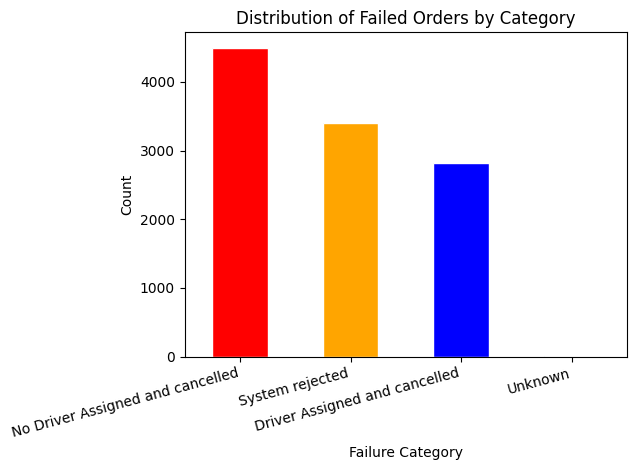

In [4]:
orders['failure_category'].value_counts().plot(kind='bar')

# customizing the plot to be more readable and visually appealing
orders['failure_category'].value_counts().plot(
    kind='bar',
    color=['red', 'orange', 'blue', 'gray'],
    edgecolor='white'
)
plt.title('Distribution of Failed Orders by Category')
plt.xlabel('Failure Category')
plt.ylabel('Count')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()

plt.show() 

**Finding:** Orders cancelled before driver assignment represent the 
largest failure category at 42% (4,496 orders), followed by system 
rejections at 32% (3,406 orders) and cancellations after driver 
assignment at 26% (2,811 orders).

The dominance of pre-assignment cancellations points to a matching 
speed problem — clients are abandoning orders before the system can 
connect them with a driver. This suggests the bottleneck lives in 
the matching algorithm, not driver behaviour.

In [5]:
print(orders['order_datetime'].dtype)
print(orders['order_datetime'].head())

str
0    18:08:07
1    20:57:32
2    12:07:50
3    13:50:20
4    21:24:45
Name: order_datetime, dtype: str


In [6]:
orders['hour'] = pd.to_datetime(orders['order_datetime'], format='%H:%M:%S').dt.hour

hourly = orders.groupby(['hour', 'failure_category']).size().unstack()
print(hourly.head())

failure_category  Driver Assigned and cancelled  \
hour                                              
0                                         120.0   
1                                          88.0   
2                                          78.0   
3                                          64.0   
4                                          41.0   

failure_category  No Driver Assigned and cancelled  System rejected  Unknown  
hour                                                                          
0                                            298.0            263.0      2.0  
1                                            219.0            164.0      NaN  
2                                            237.0            240.0      NaN  
3                                            224.0            225.0      NaN  
4                                             50.0             61.0      NaN  


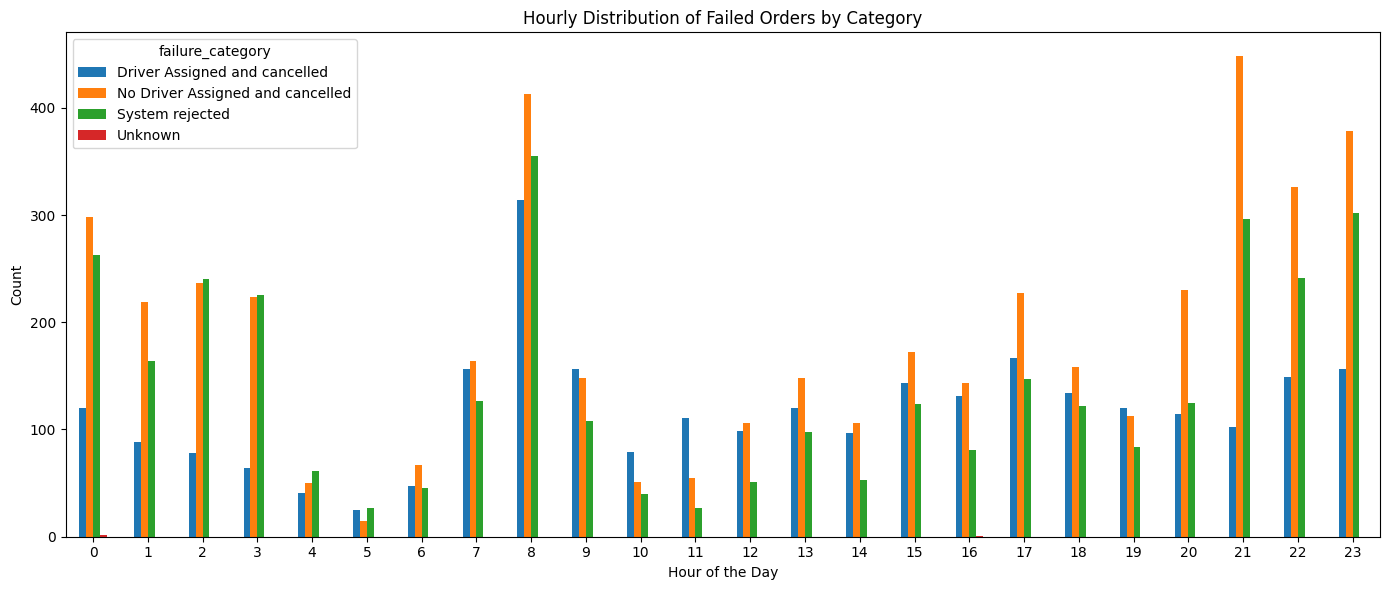

In [7]:
hourly.plot(kind='bar', figsize=(14, 6))
plt.title('Hourly Distribution of Failed Orders by Category')
plt.xlabel('Hour of the Day')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Finding:** Failures peak at two distinct windows — 8am (morning 
rush) and 21:00-23:00 (late night). Hour 8 shows the highest system 
rejection rate of any hour, suggesting the matching algorithm 
actively rejects orders when driver supply cannot meet demand spikes. 
The late night window mirrors this pattern as restaurants and bars 
close simultaneously, flooding the platform with requests. Hours 
4-6 show the lowest failure counts across all categories — 
consistent with minimal demand during the early morning.

In [8]:
print(orders['cancellations_time_in_seconds'].describe())

count    7307.000000
mean      157.892021
std       213.366963
min         3.000000
25%        45.000000
50%        98.000000
75%       187.500000
max      4303.000000
Name: cancellations_time_in_seconds, dtype: float64


In [9]:
# Removing outliers based on the 95th percentile
orders_clean = orders[orders['cancellations_time_in_seconds'] < orders['cancellations_time_in_seconds'].quantile(0.95)]
print(orders_clean['cancellations_time_in_seconds'].describe())

count    6941.000000
mean      120.847428
std       105.549597
min         3.000000
25%        43.000000
50%        92.000000
75%       171.000000
max       543.000000
Name: cancellations_time_in_seconds, dtype: float64


In [10]:
print(f"Original: {len(orders)} rows")
print(f"After outlier removal: {len(orders_clean)} rows")
print(f"Removed: {len(orders) - len(orders_clean)} rows")

Original: 10716 rows
After outlier removal: 6941 rows
Removed: 3775 rows


In [11]:
cancel_time = orders_clean.groupby(['hour', 'is_driver_assigned_key'])['cancellations_time_in_seconds'].mean().unstack()
print(cancel_time.head())

is_driver_assigned_key           0           1
hour                                          
0                       106.895270  169.000000
1                        98.132420  172.962500
2                       104.177966  193.676923
3                       102.174888  152.431373
4                        90.000000  139.117647


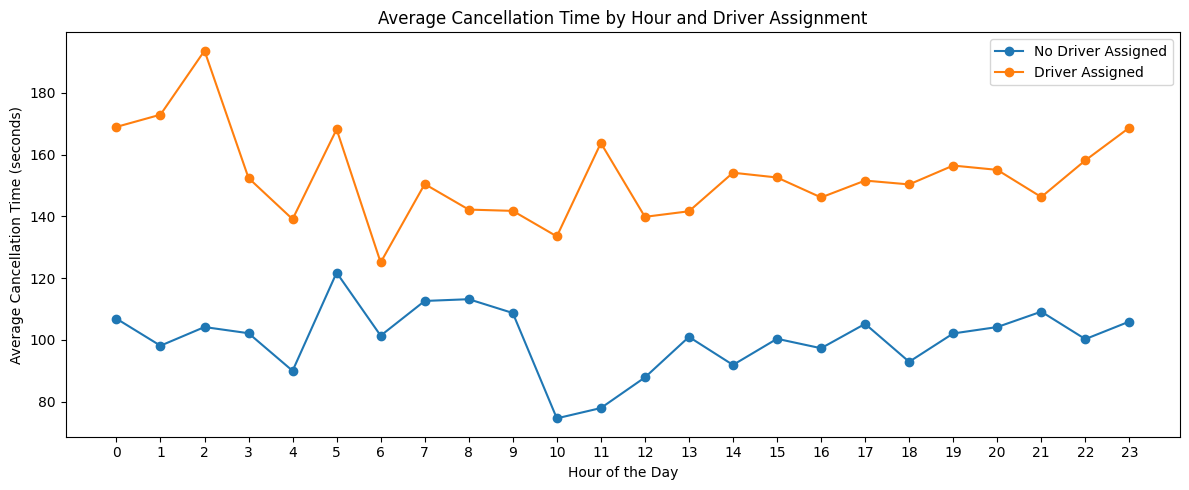

In [12]:
cancel_time.columns = ['No Driver Assigned', 'Driver Assigned']

cancel_time.plot(kind='line', figsize=(12,5), marker='o')
plt.title('Average Cancellation Time by Hour and Driver Assignment')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Cancellation Time (seconds)')
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

**Finding:** Orders with an assigned driver show consistently longer 
cancellation times — averaging 40-90 seconds more than unassigned 
orders across all hours. Confirming that driver assignment creates a psychological effect: customers are willing to wait significantly longer 
once they know a driver is coming.

Notable outliers: cancellation times peak at 2am (~190 seconds with 
driver assigned), suggesting late night riders have higher patience 
given lower driver availability expectations. Hours 
10-12 show the lowest cancellation times for both categories — 
mid-morning clients expect fast service after the rush hour window 
and abandon quickly when it doesn't arrive.

In [13]:
eta_hourly = orders.groupby('hour')['m_order_eta'].mean()
print(eta_hourly.head())

hour
0    357.959016
1    324.750000
2    391.012821
3    388.093750
4    299.658537
Name: m_order_eta, dtype: float64


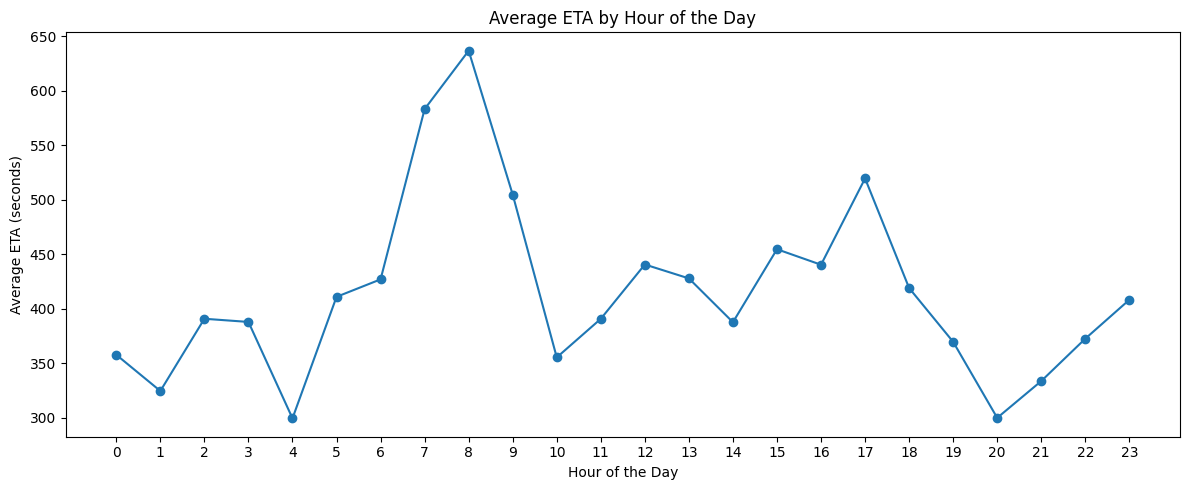

In [14]:
plot = eta_hourly.plot(kind='line', figsize=(12,5), marker='o')
plt.title('Average ETA by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Average ETA (seconds)')
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

**Findings:** The highest ETA's corelate directly to the highest amount of cancellation of rides, we can see so from hour 8 and at hour 17. The chart of hourly cancellations corelates this. The cause behind is that the system gives an ETA of 8-10 minutes, the customers see that and cancel. The opposite can be seen at hour 4 where there is low demand and low wait time as such. Giving us a direct chain high demand gives less driver avaliablity, which drives up ETA, which causes customers to cancel more often.

In [15]:
import h3
import folium

orders['hex_id'] = orders.apply(
    lambda row: h3.latlng_to_cell(row['origin_latitude'], 
                                   row['origin_longitude'], 8), 
    axis=1
)

print(orders['hex_id'].value_counts().head(10))

hex_id
88195d2b1dfffff    1497
88195d2b1bfffff     870
88195d2b15fffff     774
88195d2b11fffff     707
88195d2b19fffff     667
88195d284dfffff     653
88195d2a27fffff     414
88195d2b0bfffff     372
88195d2a25fffff     362
88195d2b13fffff     346
Name: count, dtype: int64


In [16]:
# count orders per hexagon
hex_counts = orders['hex_id'].value_counts().reset_index()
hex_counts.columns = ['hex_id', 'count']

# calculate cumulative percentage as a separate step
cumulative = hex_counts['count'].cumsum()
total = hex_counts['count'].sum()
hex_counts['cumulative_pct'] = cumulative / total * 100

# find hexagons that contain 80% of orders
hex_80 = hex_counts[hex_counts['cumulative_pct'] <= 80]

print(f"Total hexagons: {len(hex_counts)}")
print(f"Hexagons containing 80% of orders: {len(hex_80)}")

Total hexagons: 144
Hexagons containing 80% of orders: 23


In [18]:
import matplotlib.colors as mcolors

# create color scale
max_count = hex_80['count'].max()
colormap = plt.cm.Reds

m = folium.Map(location=[0, 0], zoom_start=12)

for _, row in hex_80.iterrows():
    hex_boundary = h3.cell_to_boundary(row['hex_id'])
    hex_boundary = [[lat, lng] for lat, lng in hex_boundary]
    
    # scale color by order count
    intensity = row['count'] / max_count
    color = mcolors.to_hex(colormap(intensity))
    
    folium.Polygon(
        locations=hex_boundary,
        fill=True,
        fill_opacity=0.7,
        color=color,
        fill_color=color,
        tooltip=f"Orders: {row['count']}"
    ).add_to(m)

m.save('hex_map.html')

**Finding:** what we can see from the map is that most of the orders are happening in the city centre(Reading Town Centre) at 1497 and the college campus areas of St. Joseph's college and University of Reading whiteknights campus. Confirming that most orders are made by workers during the day and people going out late at night as we've seen in the earlier graphs, and by students near the campuses.

## Conclusions

This analysis identified four key drivers of taxi order failure on the Gett platform:

1. **Failure type:** Pre driver assignment cancellations at 42%, pointing 
   to matching speed as the primary bottleneck
2. **Timing:** Failures spike at 8am and 21-23:00, beacuse of demand 
   surpassing driver supply during rush hours
3. **Patience:** Customers wait ~40-90 seconds longer when a driver is 
   assigned, confirming that fast assignment reduces cancellations
4. **Geography:** 23 hexagons contain 80% of failures, concentrated around 
   Reading Town Centre and university campuses